In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
from pathlib import Path

np.random.seed(0)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True

Theoretical free-space path loss at d0 = 1.0 m, fc = 3.5 GHz: FSPL(d0) = 43.323 dB
[Fallback] 'pathloss.txt' not found -- using a synthetic measurement campaign (true n = 3.0, true sigma = 6.0 dB, N = 150 points, d in [10.3, 1764.3] m).


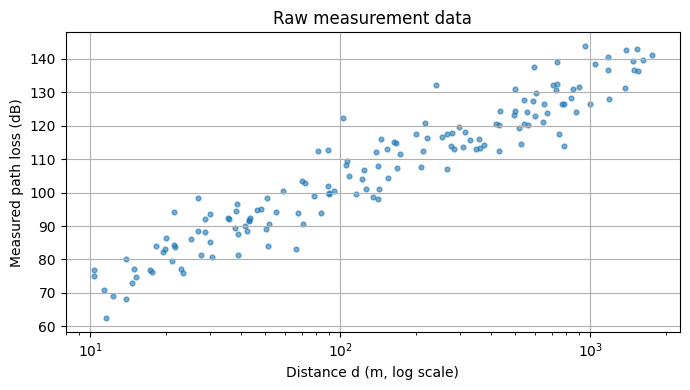

In [2]:
c = 3e8          # speed of light, m/s
fc = 3.5e9       # carrier frequency, Hz (n78 band)
d0 = 1.0         # reference distance, m

FSPL_d0_theory = 20 * np.log10(4 * np.pi * d0 * fc / c)
print(f"Theoretical free-space path loss at d0 = {d0} m, fc = {fc/1e9} GHz: "
      f"FSPL(d0) = {FSPL_d0_theory:.3f} dB")


def synthesize_pathloss(n_true, sigma_true, n_samples=150, d_min=10.0, d_max=1800.0, seed=1):
    """Synthetic measurement campaign following the CI model:
    PL(d) = FSPL(d0) + 10*n*log10(d/d0) + X_sigma,  X_sigma ~ N(0, sigma^2).
    Distances are log-uniformly spaced, as is typical for a real drive-test measurement campaign.
    """
    rng = np.random.default_rng(seed)
    log_d = rng.uniform(np.log10(d_min), np.log10(d_max), size=n_samples)
    d = 10 ** log_d
    shadowing = rng.normal(0, sigma_true, size=n_samples)
    PL = FSPL_d0_theory + 10 * n_true * np.log10(d / d0) + shadowing
    return d, PL


DATA_PATH = Path("pathloss.txt")
# Ground truth used ONLY for the synthetic fallback -- hidden from every fitting routine below.
N_TRUE, SIGMA_TRUE = 3.0, 6.0

if DATA_PATH.exists():
    data = np.loadtxt(DATA_PATH)
    d_meas, PL_meas = data[:, 0], data[:, 1]
    print(f"Loaded REAL measurement file: {DATA_PATH} ({len(d_meas)} points).")
else:
    d_meas, PL_meas = synthesize_pathloss(N_TRUE, SIGMA_TRUE)
    print(f"[Fallback] '{DATA_PATH}' not found -- using a synthetic measurement campaign "
          f"(true n = {N_TRUE}, true sigma = {SIGMA_TRUE} dB, N = {len(d_meas)} points, "
          f"d in [{d_meas.min():.1f}, {d_meas.max():.1f}] m).")

plt.figure(figsize=(7, 4))
plt.scatter(d_meas, PL_meas, s=12, alpha=0.6)
plt.xscale("log")
plt.xlabel("Distance d (m, log scale)"); plt.ylabel("Measured path loss (dB)")
plt.title("Raw measurement data")
plt.tight_layout(); plt.show()

In [3]:
class MyLinearRegression:
    """Simple linear regression y = theta0 + theta1 * x, implemented from scratch with NumPy only."""

    def __init__(self):
        self.theta = None          # [intercept, slope] after fitting
        self.loss_history_ = None  # per-epoch MSE, populated for iterative methods

    @staticmethod
    def _design_matrix(x):
        x = np.asarray(x).reshape(-1)
        return np.column_stack([np.ones_like(x), x])

    @staticmethod
    def _mse(Phi, y, theta):
        residual = Phi @ theta - y
        return np.mean(residual ** 2)

    def fit(self, x, y, method="closed_form", lr=1e-3, epochs=2000, random_state=0):
        Phi = self._design_matrix(x)
        y = np.asarray(y).reshape(-1)
        n = len(y)

        if method == "closed_form":
            # Normal equation: theta = (Phi^T Phi)^{-1} Phi^T y
            self.theta = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
            self.loss_history_ = None

        elif method == "batch_gd":
            theta = np.zeros(2)
            history = np.empty(epochs)
            for epoch in range(epochs):
                residual = Phi @ theta - y
                grad = (2.0 / n) * (Phi.T @ residual)
                theta = theta - lr * grad
                history[epoch] = self._mse(Phi, y, theta)
            self.theta = theta
            self.loss_history_ = history

        elif method == "sgd":
            rng = np.random.default_rng(random_state)
            theta = np.zeros(2)
            history = np.empty(epochs)
            for epoch in range(epochs):
                order = rng.permutation(n)
                for i in order:
                    phi_i = Phi[i]
                    residual_i = phi_i @ theta - y[i]
                    grad_i = 2.0 * residual_i * phi_i
                    theta = theta - lr * grad_i
                # record the FULL-dataset MSE at the end of each epoch, so it is directly
                # comparable to batch_gd's per-epoch loss curve, even though updates within
                # the epoch used only one sample at a time.
                history[epoch] = self._mse(Phi, y, theta)
            self.theta = theta
            self.loss_history_ = history

        else:
            raise ValueError(f"Unknown method '{method}'. Use 'closed_form', 'batch_gd', or 'sgd'.")
        return self

    def predict(self, x):
        Phi = self._design_matrix(x)
        return Phi @ self.theta

    @property
    def intercept_(self):
        return self.theta[0]

    @property
    def slope_(self):
        return self.theta[1]


print("MyLinearRegression implemented with methods: closed_form, batch_gd, sgd.")

MyLinearRegression implemented with methods: closed_form, batch_gd, sgd.


lr=0.5      final MSE (500 epochs) = DIVERGED (overflow)
lr=0.2      final MSE (500 epochs) = DIVERGED (overflow)
lr=0.1      final MSE (500 epochs) = 33.6428
lr=0.05     final MSE (500 epochs) = 33.7079
lr=0.01     final MSE (500 epochs) = 46.5509
lr=0.001    final MSE (500 epochs) = 75.9887
     Method  FSPL(d0) [dB]  n (path-loss exp.)
Closed-form      42.569518            2.998803
   Batch GD      42.568286            2.998856
        SGD      41.374047            2.988131


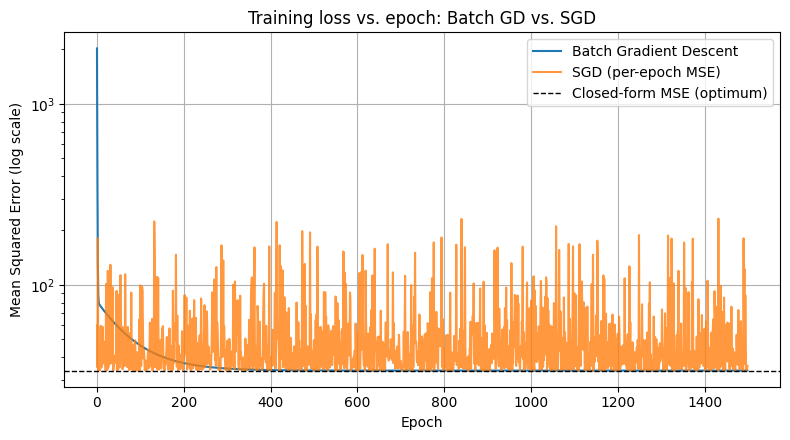

In [4]:
x_feat = np.log10(d_meas / d0)
y_target = PL_meas

import warnings

for lr_test in [0.5, 0.2, 0.1, 0.05, 0.01, 1e-3]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        model_test = MyLinearRegression().fit(x_feat, y_target, method="batch_gd", lr=lr_test, epochs=500)
    final_loss = model_test.loss_history_[-1]
    diverged = not np.isfinite(final_loss) or final_loss > 1e6
    print(f"lr={lr_test:<8g} final MSE (500 epochs) = "
          f"{'DIVERGED (overflow)' if diverged else f'{final_loss:.4f}'}")

LR, EPOCHS = 0.05, 1500

model_cf = MyLinearRegression().fit(x_feat, y_target, method="closed_form")
model_gd = MyLinearRegression().fit(x_feat, y_target, method="batch_gd", lr=LR, epochs=EPOCHS)
model_sgd = MyLinearRegression().fit(x_feat, y_target, method="sgd", lr=LR, epochs=EPOCHS, random_state=0)

results = pd.DataFrame({
    "Method": ["Closed-form", "Batch GD", "SGD"],
    "FSPL(d0) [dB]": [model_cf.intercept_, model_gd.intercept_, model_sgd.intercept_],
    "n (path-loss exp.)": [model_cf.slope_ / 10, model_gd.slope_ / 10, model_sgd.slope_ / 10],
})
print(results.to_string(index=False))

plt.figure(figsize=(8, 4.5))
plt.semilogy(model_gd.loss_history_, label="Batch Gradient Descent")
plt.semilogy(model_sgd.loss_history_, label="SGD (per-epoch MSE)", alpha=0.8)
plt.axhline(MyLinearRegression._mse(MyLinearRegression._design_matrix(x_feat), y_target, model_cf.theta),
            color="black", linestyle="--", linewidth=1, label="Closed-form MSE (optimum)")
plt.xlabel("Epoch"); plt.ylabel("Mean Squared Error (log scale)")
plt.title("Training loss vs. epoch: Batch GD vs. SGD")
plt.legend(); plt.tight_layout(); plt.show()